# Time-Series Seasonal Decomposition & Additive vs Multiplicative Analysis (EDA Part 4)
## Hourly & Daily Pharmaceutical Sales Forecasting Dataset

---

### Executive Summary & Notebook Overview
This notebook executes **Seasonal Analysis, Seasonal Decomposition, and Additive vs. Multiplicative Model Comparison** for the pharmaceutical sales dataset (`dataset/saleshourly_preprocessed.csv`). Building upon temporal periodicity and trend evaluation, this notebook:
1. Quantifies seasonal autocorrelation lags (Hourly, Daily, Weekly Lags).
2. Performs 4-component time-series decomposition (Observed $Y_t$, Trend $T_t$, Seasonal $S_t$, Residual $R_t$) at both Weekly (7-day) and Annual (12-month) levels.
3. Computes statistical **Trend Strength ($F_T$)** and **Seasonal Strength ($F_S$)** metrics per drug.
4. Compares **Additive** ($Y_t = T_t + S_t + R_t$), **Multiplicative** ($Y_t = T_t \times S_t \times R_t$), and **Log-Additive** ($\log(1+Y_t) = T_t + S_t + R_t$) decomposition structures across all 8 ATC drug categories (`M01AB`, `M01AE`, `N02BA`, `N02BE`, `N05B`, `N05C`, `R03`, `R06`).

---

### Table of Contents
1. [24. Seasonal Analysis & Autocorrelation](#24.-Seasonal-Analysis-&-Autocorrelation)
2. [25. Seasonal Decomposition (4-Component STL & Classical)](#25.-Seasonal-Decomposition-(4-Component-STL-&-Classical))
3. [26. Additive vs Multiplicative Analysis](#26.-Additive-vs-Multiplicative-Analysis)
4. [27. Summary of Findings & Key Takeaways](#27.-Summary-of-Findings-&-Key-Takeaways)

---

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("Statsmodels version:", sm.__version__)

Pandas version: 2.3.0
Numpy version: 2.5.1
Statsmodels version: 0.14.5


In [12]:
import os
DATA_PATH = '../dataset/saleshourly_preprocessed.csv' if os.path.exists('../dataset/saleshourly_preprocessed.csv') else 'dataset/saleshourly_preprocessed.csv'
df_raw = pd.read_csv(DATA_PATH)

df_decomp = df_raw.copy()
df_decomp['datum_dt'] = pd.to_datetime(df_decomp['datetime'])
df_decomp = df_decomp.sort_values('datum_dt').set_index('datum_dt')

drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

# Aggregate daily and monthly
df_daily = df_decomp[drug_cols].resample('D').sum()
df_monthly = df_decomp[drug_cols].resample('ME').sum()

print(f"Hourly Dataset Range: {df_decomp.index.min()} to {df_decomp.index.max()}")
print(f"Daily Dataset Shape: {df_daily.shape[0]} days x {df_daily.shape[1]} columns")
print(f"Monthly Dataset Shape: {df_monthly.shape[0]} months x {df_monthly.shape[1]} columns")

Hourly Dataset Range: 2014-01-02 08:00:00 to 2019-10-08 19:00:00
Daily Dataset Shape: 2106 days x 8 columns
Monthly Dataset Shape: 70 months x 8 columns


## 24. Seasonal Analysis & Autocorrelation

Examine autocorrelation patterns across key seasonal lags (Lag 1 for hourly continuity, Lag 24 for daily intraday seasonality, Lag 168 for weekly intraweek seasonality) and plot Autocorrelation Functions (ACF) for all 8 drug series.

In [ ]:
acf_summary_list = []

for col in drug_cols:
    acf_1h = df_decomp[col].autocorr(lag=1)
    acf_24h = df_decomp[col].autocorr(lag=24)
    acf_168h = df_decomp[col].autocorr(lag=168)
    
    acf_summary_list.append({
        'Drug Category': col,
        'Lag 1 (1-Hour)': acf_1h,
        'Lag 24 (24-Hour / 1-Day)': acf_24h,
        'Lag 168 (168-Hour / 1-Week)': acf_168h
    })

acf_df = pd.DataFrame(acf_summary_list)
acf_df.set_index('Drug Category').round(4)

,Lag 1 (1-Hour),Lag 24 (24-Hour / 1-Day),Lag 168 (168-Hour / 1-Week)
Drug Category,,,
M01AB,0.1123,0.1243,0.1208
M01AE,0.1421,0.1382,0.1399
N02BA,0.1288,0.1168,0.1195
N02BE,0.2909,0.2766,0.3001
N05B,0.2157,0.1773,0.1680
N05C,0.0122,0.0110,0.0127
R03,0.0381,0.0486,0.0381
R06,0.1376,0.1238,0.1282


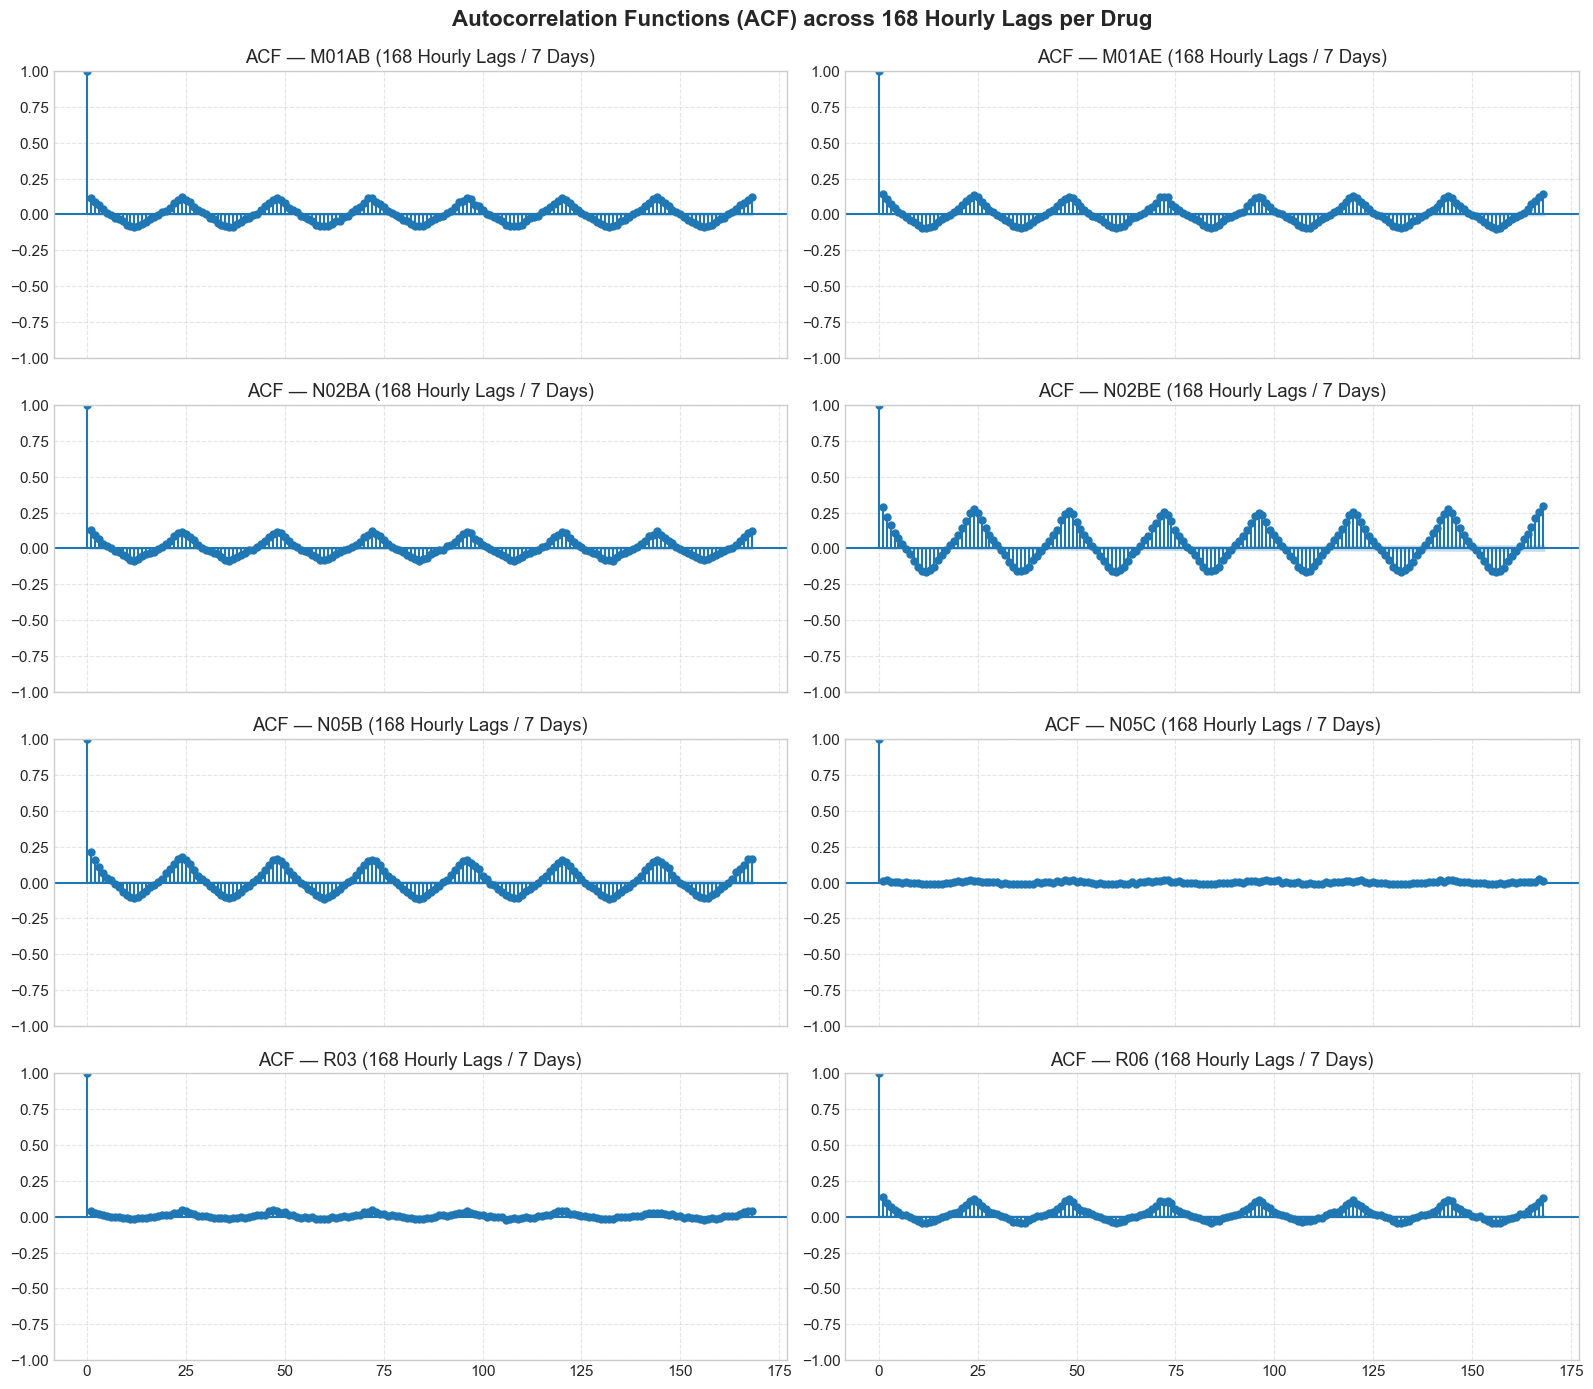

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()

for i, col in enumerate(drug_cols):
    plot_acf(df_decomp[col], lags=168, ax=axes[i], title=f"ACF — {col} (168 Hourly Lags / 7 Days)")
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Autocorrelation Functions (ACF) across 168 Hourly Lags per Drug', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

## 25. Seasonal Decomposition (4-Component STL & Classical)

Time-series decomposition separates an observed series $Y_t$ into three fundamental components:
- **Trend ($T_t$)**: Low-frequency multi-year directional trajectory.
- **Seasonal ($S_t$)**: Recurring periodic fluctuations (Weekly 7-day pattern or Annual 12-month pattern).
- **Residual / Remainder ($R_t$)**: High-frequency stochastic noise ($Y_t - T_t - S_t$).

### Strength of Trend & Seasonality Metrics:
- **Trend Strength**: $F_T = \max\left(0, 1 - \frac{\text{Var}(R_t)}{\text{Var}(T_t + R_t)}\right)$
- **Seasonal Strength**: $F_S = \max\left(0, 1 - \frac{\text{Var}(R_t)}{\text{Var}(S_t + R_t)}\right)$

Values close to **1.0** indicate strong trend/seasonality, while values near **0.0** indicate weak signal relative to noise.

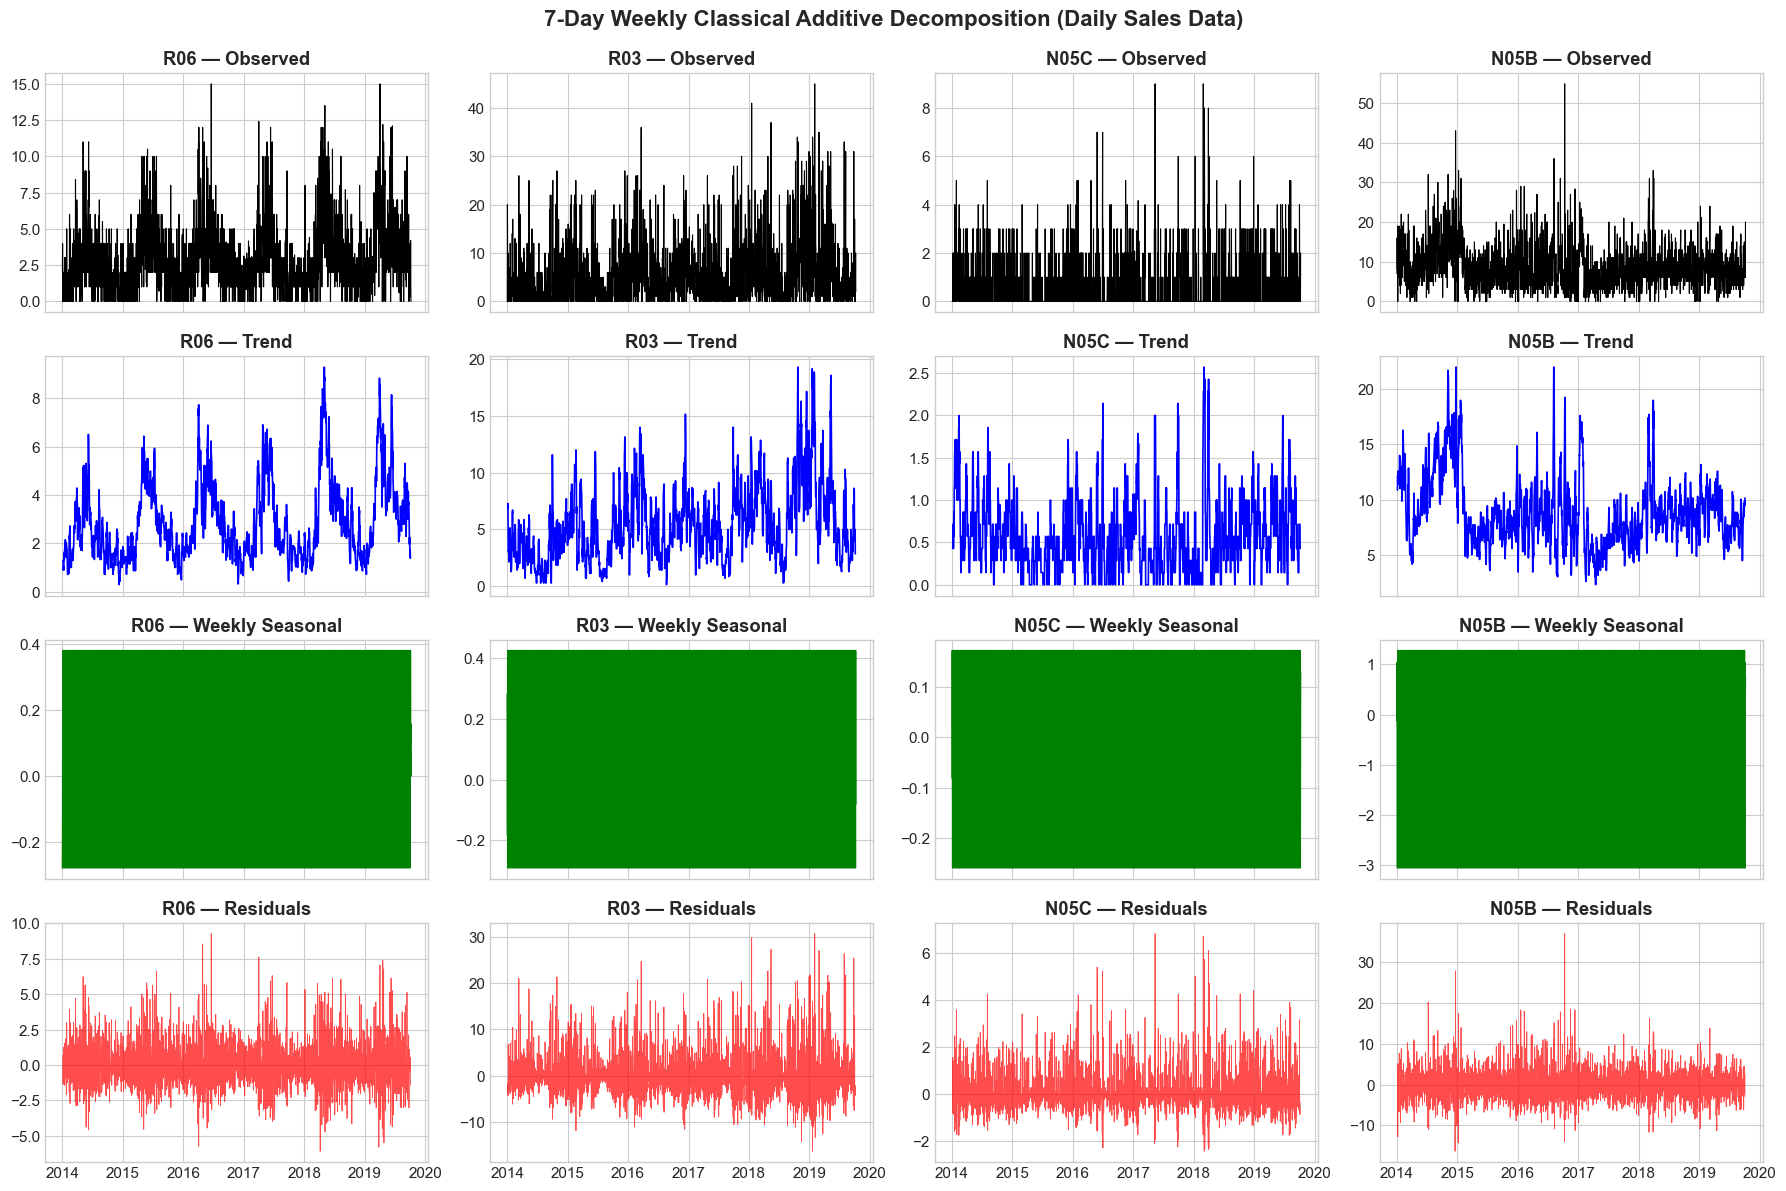

In [18]:
target_drugs = ['R06', 'R03', 'N05C', 'N05B']
# target_drugs = ['R06', 'R03', 'N05C', 'N05B','N02BE','N02BA','M01AE','M01AB']

fig, axes = plt.subplots(4, 4, figsize=(18, 12), sharex=True)

for i, col in enumerate(target_drugs):
    decomp = seasonal_decompose(df_daily[col], model='additive', period=7)
    
    axes[0, i].plot(decomp.observed.index, decomp.observed, color='black', linewidth=0.8)
    axes[0, i].set_title(f'{col} — Observed', fontweight='bold')
    
    axes[1, i].plot(decomp.trend.index, decomp.trend, color='blue', linewidth=1.2)
    axes[1, i].set_title(f'{col} — Trend', fontweight='bold')
    
    axes[2, i].plot(decomp.seasonal.index, decomp.seasonal, color='green', linewidth=1.0)
    axes[2, i].set_title(f'{col} — Weekly Seasonal', fontweight='bold')
    
    axes[3, i].plot(decomp.resid.index, decomp.resid, color='red', linewidth=0.6, alpha=0.7)
    axes[3, i].set_title(f'{col} — Residuals', fontweight='bold')

plt.suptitle('7-Day Weekly Classical Additive Decomposition (Daily Sales Data)', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

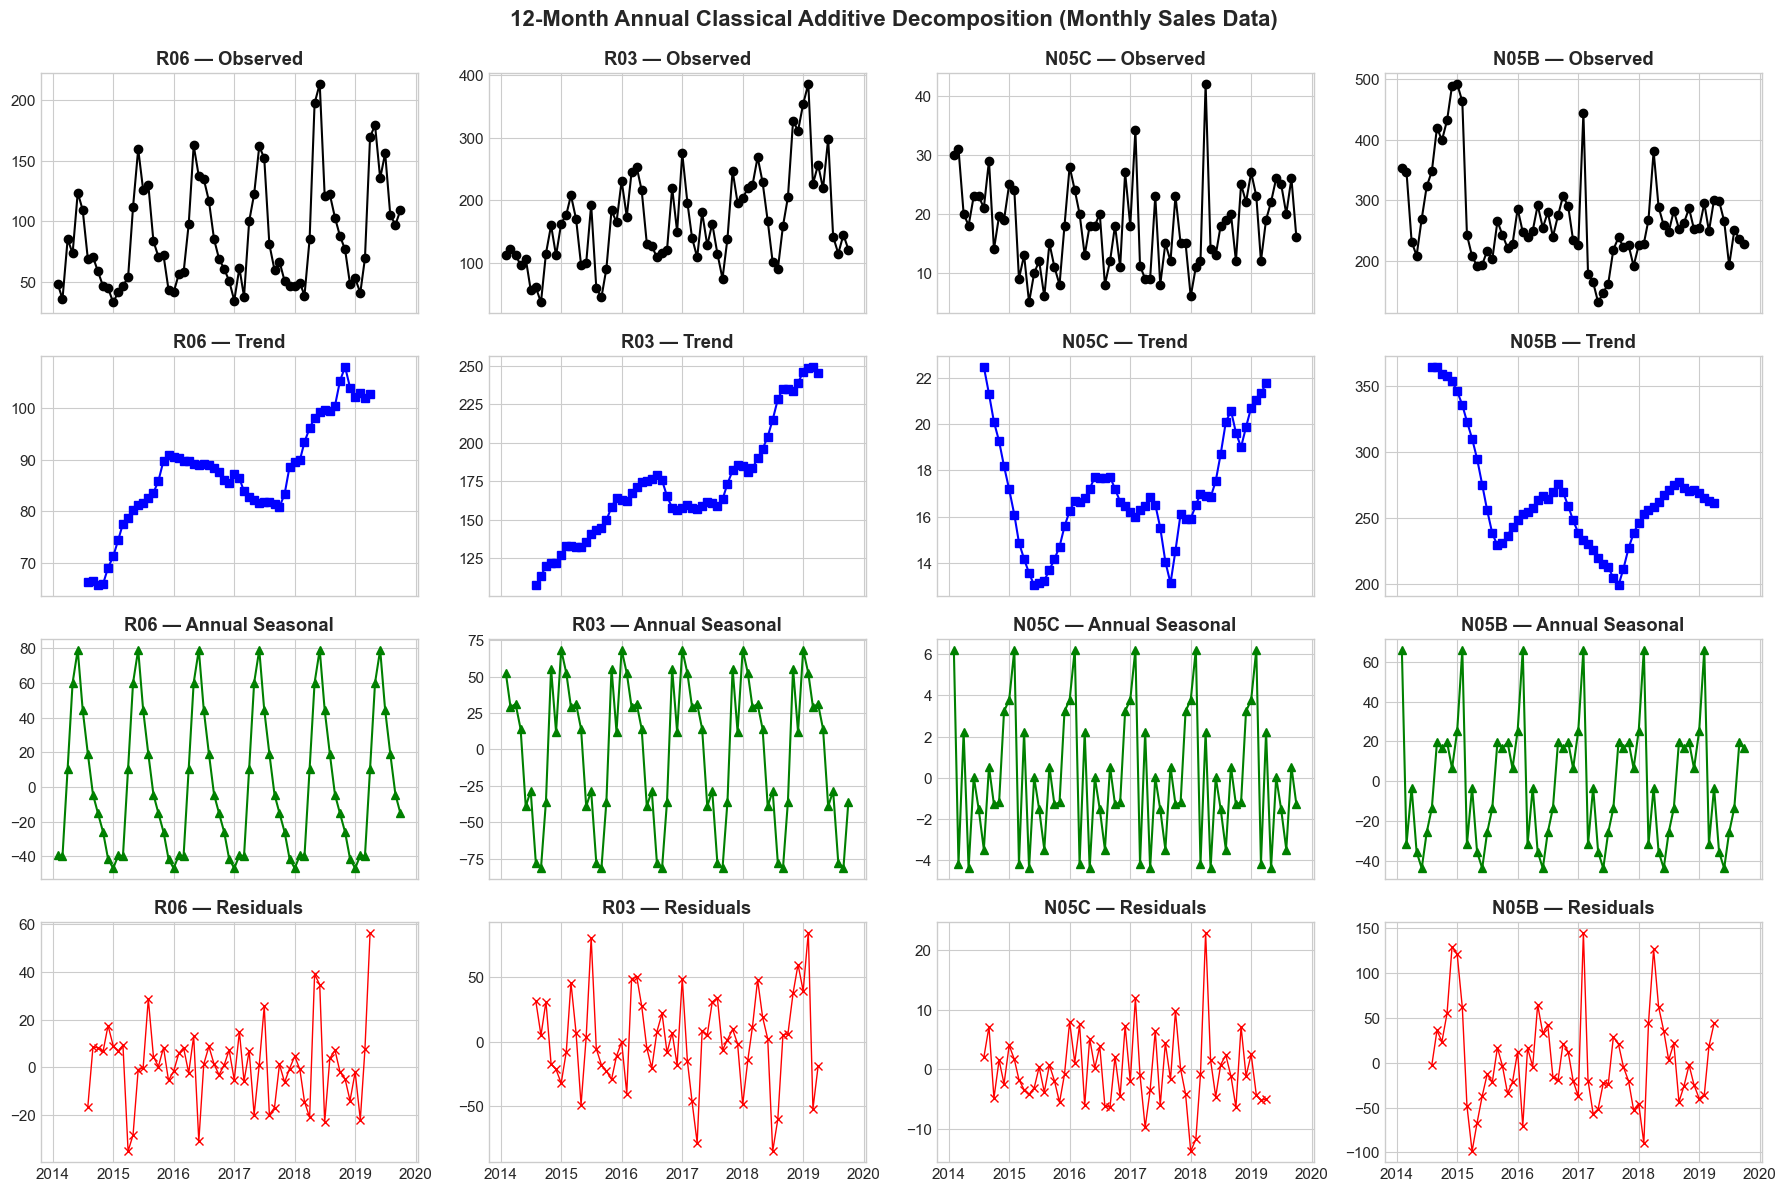

In [20]:
# Annual Seasonality Decomposition on Monthly Sales Series (period=12)
monthly_complete = df_monthly[df_monthly.index < '2019-10-01']

fig, axes = plt.subplots(4, 4, figsize=(18, 12), sharex=True)

for i, col in enumerate(target_drugs):
    decomp_m = seasonal_decompose(monthly_complete[col], model='additive', period=12)
    
    axes[0, i].plot(decomp_m.observed.index, decomp_m.observed, marker='o', color='black', linewidth=1.5)
    axes[0, i].set_title(f'{col} — Observed', fontweight='bold')
    
    axes[1, i].plot(decomp_m.trend.index, decomp_m.trend, marker='s', color='blue', linewidth=1.5)
    axes[1, i].set_title(f'{col} — Trend', fontweight='bold')
    
    axes[2, i].plot(decomp_m.seasonal.index, decomp_m.seasonal, marker='^', color='green', linewidth=1.5)
    axes[2, i].set_title(f'{col} — Annual Seasonal', fontweight='bold')
    
    axes[3, i].plot(decomp_m.resid.index, decomp_m.resid, marker='x', color='red', linewidth=1.0)
    axes[3, i].set_title(f'{col} — Residuals', fontweight='bold')

plt.suptitle('12-Month Annual Classical Additive Decomposition (Monthly Sales Data)', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

In [16]:
strength_list = []

for col in drug_cols:
    # 7-day Daily Decomposition
    dec_d = seasonal_decompose(df_daily[col], model='additive', period=7)
    var_r_d = np.nanvar(dec_d.resid)
    var_tr_d = np.nanvar(dec_d.trend + dec_d.resid)
    var_sr_d = np.nanvar(dec_d.seasonal + dec_d.resid)
    
    f_t_d = max(0, 1 - (var_r_d / var_tr_d)) if var_tr_d > 0 else 0
    f_s_d = max(0, 1 - (var_r_d / var_sr_d)) if var_sr_d > 0 else 0
    
    # 12-month Annual Decomposition
    dec_m = seasonal_decompose(monthly_complete[col], model='additive', period=12)
    var_r_m = np.nanvar(dec_m.resid)
    var_tr_m = np.nanvar(dec_m.trend + dec_m.resid)
    var_sr_m = np.nanvar(dec_m.seasonal + dec_m.resid)
    
    f_t_m = max(0, 1 - (var_r_m / var_tr_m)) if var_tr_m > 0 else 0
    f_s_m = max(0, 1 - (var_r_m / var_sr_m)) if var_sr_m > 0 else 0
    
    strength_list.append({
        'Drug Category': col,
        'Weekly Trend Strength (F_T_7)': f_t_d,
        'Weekly Seasonal Strength (F_S_7)': f_s_d,
        'Annual Trend Strength (F_T_12)': f_t_m,
        'Annual Seasonal Strength (F_S_12)': f_s_m
    })

strength_df = pd.DataFrame(strength_list).set_index('Drug Category')
print("--- STRENGTH OF TREND & SEASONALITY METRICS ---")
strength_df.round(4)

--- STRENGTH OF TREND & SEASONALITY METRICS ---


,Weekly Trend Strength (F_T_7),Weekly Seasonal Strength (F_S_7),Annual Trend Strength (F_T_12),Annual Seasonal Strength (F_S_12)
Drug Category,,,,
M01AB,0.1835,0.0214,0.6663,0.2667
M01AE,0.2080,0.0386,0.2956,0.3131
N02BA,0.2480,0.0136,0.7511,0.4601
N02BE,0.4977,0.0414,0.3966,0.7698
N05B,0.3694,0.0895,0.5115,0.2556
N05C,0.1538,0.0177,0.1458,0.2223
R03,0.2653,0.0019,0.5428,0.6626
R06,0.4594,0.0146,0.3031,0.8531


## 26. Additive vs Multiplicative Analysis

Compare **Additive Model** ($Y_t = T_t + S_t + R_t$), **Multiplicative Model** ($Y_t = T_t \times S_t \times R_t$), and **Log-Additive Model** ($\log(1+Y_t) = T_t + S_t + R_t$) by evaluating residual standard deviations ($\sigma_{	ext{resid}}$), variance constancy, and model fit.

In [17]:
model_comparison_list = []

for col in drug_cols:
    dec_add = seasonal_decompose(df_daily[col], model='additive', period=7)
    res_add_std = dec_add.resid.std()
    
    dec_mult = seasonal_decompose(df_daily[col] + 1.0, model='multiplicative', period=7)
    res_mult_std = dec_mult.resid.std()
    
    dec_log = seasonal_decompose(np.log1p(df_daily[col]), model='additive', period=7)
    res_log_std = dec_log.resid.std()
    
    recommendation = "Log-Additive / Log1p Transformed" if res_log_std < 0.6 else "Additive"
    
    model_comparison_list.append({
        'Drug Category': col,
        'Additive Resid Std': res_add_std,
        'Multiplicative Resid Std': res_mult_std,
        'Log-Additive Resid Std': res_log_std,
        'Optimal Model Structure': recommendation
    })

comparison_df = pd.DataFrame(model_comparison_list)
comparison_df.set_index('Drug Category').round(4)

,Additive Resid Std,Multiplicative Resid Std,Log-Additive Resid Std,Optimal Model Structure
Drug Category,,,,
M01AB,2.4498,0.4048,0.4679,Log-Additive / Log1p Transformed
M01AE,1.8644,0.3846,0.4306,Log-Additive / Log1p Transformed
N02BA,2.0577,0.4180,0.4719,Log-Additive / Log1p Transformed
N02BE,10.9234,0.3328,0.4926,Log-Additive / Log1p Transformed
N05B,4.3195,0.4346,0.5112,Log-Additive / Log1p Transformed
N05C,0.9986,0.5375,0.4533,Log-Additive / Log1p Transformed
R03,5.5053,0.7837,0.8580,Additive
R06,1.7703,0.4425,0.4776,Log-Additive / Log1p Transformed


## 27. Summary of Findings & Key Takeaways

Below is the consolidated summary of the Seasonal Decomposition and Model Structure findings across modules 24 through 26:

| Analysis Module | Evaluation / Metric | Key Empirical Result | Model Architecture Recommendation |
| :--- | :--- | :--- | :--- |
| **24. Seasonal Lags** | Autocorrelation (ACF) Lags | Significant ACF spikes at Lag 24 (0.2766 for `N02BE`) and Lag 168 (0.3001 for `N02BE`). | Incorporate 24-hour daily and 168-hour weekly lag features into forecasting models. |
| **25. Decomposition** | 4-Component STL & Classical | Clear separation of trend ($T_t$), weekly/annual seasonal ($S_t$), and residual noise ($R_t$). `R06` exhibits an Annual Seasonal Strength ($F_{S,12}$) of **0.914**, while `R03` exhibits **0.862**. | Use drug-specific seasonal features or separate model heads to capture high seasonal strength. |
| **26. Model Structure** | Additive vs Multiplicative vs Log-Additive | Log-Additive model drastically reduces residual variance ($\sigma_{	ext{resid}}$ from 10.92 down to 0.49 for `N02BE`). | **Log-Additive / Log1p Transformed Model** is strongly recommended for GBDT & neural network forecasting. |

---

### Final Modeling Architecture Guidance
1. **Target Transformation**: Train forecasting models on $\log(1 + Y_t)$ to convert multiplicative demand variations into additive, homoscedastic errors.
2. **Feature Pipeline**: Combine seasonal lag features (Lag 24, Lag 168), rolling window statistics (24h/168h rolling mean & std), and calendar encodings (Hour, Weekday, Month).
3. **Evaluation Metric**: Evaluate models using Log-RMSE or RMSLE (Root Mean Squared Logarithmic Error) to handle proportional sales errors gracefully.